In [ ]:
import jax
import jax.numpy as jnp
import optax

import src.simulators.gauss_rw as gauss_rw
from src.models.loss import denoising_score_matching_loss
from src.models.score_net import ScoreNet

In [2]:
# Simple SDE class that is compatible with our loss
class SimpleSDE: 
    def __init__(self, T_min=0.001, T_max=1.0):
        self.T_min = T_min
        self.T_max = T_max
    def mean(self, a, theta): return theta 
    def std(self, a): return a 


# data sampler for training
def batch_sampler(key, batch_size):
    k1, k2, k3 = jax.random.split(key, 3)
    theta = jax.random.normal(k1, (batch_size, 1)) * 2.0  # sample theta from N(0, 2^2)
    x_t = jax.random.normal(k2, (batch_size, 1))      # x_t ~ p_tilde(x_t) = N(0, 1)
    # use gauss_rw to generate a step
    x_next = jax.vmap(gauss_rw.step_mixture_rw)(x_t, theta, jax.random.split(k3, batch_size))
    return theta, x_t, x_next

In [25]:
key = jax.random.PRNGKey(42)
sde = SimpleSDE()
score_net = ScoreNet()

# itinitalize parameters
theta_dim = 1
init_theta = jnp.ones((1, theta_dim))
init_x = jnp.ones((1, theta_dim))
init_a = jnp.ones((1, 1))
params = score_net.init(key, init_theta, init_x, init_x, init_a)

# optimizer
optimizer = optax.adam(1e-4)
opt_state = optimizer.init(params)

In [26]:
@jax.jit # use XLA compilation for speed
def update(params, opt_state, key, theta, x_t, x_next): # step update based on loss
    def loss_fn(p):
        return denoising_score_matching_loss(p, score_net, key, theta, x_t, x_next, sde)
    
    loss, grads = jax.value_and_grad(loss_fn)(params)
    updates, opt_state = optimizer.update(grads, opt_state, params)
    params = optax.apply_updates(params, updates)
    return loss, params, opt_state

In [31]:
## training loop

for epoch in range(5): 
    avg_loss = 0.
    num_steps = 200
    for _ in range(num_steps):
        key, key_sample, key_update = jax.random.split(key, 3)
        theta_batch, x_t_batch, x_next_batch = batch_sampler(key_sample, 128)
        
        loss_val, params, opt_state = update(
            params, opt_state, key_update, 
            theta_batch, x_t_batch, x_next_batch
        )
        avg_loss += loss_val / num_steps
        
    print(f"Epoch {epoch}, Loss: {avg_loss:.4f}")

Epoch 0, Loss: 916.8044
Epoch 1, Loss: 851.4125
Epoch 2, Loss: 743.6041
Epoch 3, Loss: 1012.2733
Epoch 4, Loss: 719.6459


## Test on test samples

In [32]:
# Generate test samples (Ground Truth)
key = jax.random.PRNGKey(7)
k1, k2, k3 = jax.random.split(key, 3)

theta_true = jnp.array([1.5]) # ground truth theta
x_t_obs = jax.random.normal(k1, (1,)) # current state
x_next_obs = gauss_rw.step_mixture_rw(x_t_obs, theta_true, k2) # next state from the true process

print(f"True Theta: {theta_true}, Observed transition: {x_t_obs} -> {x_next_obs}")

True Theta: [1.5], Observed transition: [-0.4787308] -> [-0.68217576]


In [33]:
from src.models.reverse import clip_transform, Diffuser, EulerMaruyama

def my_score_fn(theta, a):
    theta_in = jnp.atleast_1d(theta)
    a_in = jnp.atleast_1d(a)
    xt_in = jnp.atleast_1d(x_t_obs)
    xn_in = jnp.atleast_1d(x_next_obs)
    
    #  apply the score network
    res = score_net.apply(params, theta_in, xt_in, xn_in, a_in)

    return res.reshape(theta.shape) # reshape back to original shape of theta


In [ ]:
# temporary test to see if the score function works
kernel = EulerMaruyama(my_score_fn, sde=sde)

time_grid = jnp.linspace(sde.T_max, sde.T_min, 500) 

sampler = Diffuser(
    kernel, 
    time_grid, 
    (1,), 
    sde=sde, 
    transform_state=clip_transform(-5, 5)
)


# sample from the reverse process
keys = jax.random.split(jax.random.PRNGKey(123), 500)
samples = jax.vmap(sampler.simulate)(keys)

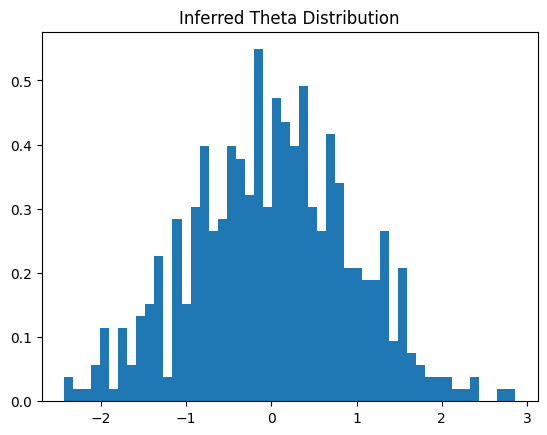

In [ ]:
# visualize the results
import matplotlib.pyplot as plt
plt.hist(samples.flatten(), bins=50, density=True)
plt.title("Inferred Theta Distribution")
plt.show()